# Week 5 Lab: Build attention and a small GPT, then interrogate real transformers

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3

This lab balances **coding, visualisation and critical thinking**:

1. implement **scaled dot-product attention** and check it against PyTorch;
2. add a **causal mask**, and show that attention without positions ignores word order;
3. implement **multi-head attention** and a pre-norm **transformer block**;
4. train a **character-level GPT** on Tiny Shakespeare, measure **perplexity** and sample text;
5. **interrogate** pretrained BERT and GPT-2 attention and judge what it does and does not explain;
6. (optional) measure the speed-up from the **KV cache**.

Every implementation step has an automatic check: a ✅ means your code matches the reference.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Start here: the complete journey

The small model in this lab reads **characters**, not whole words. Start with
text, turn its characters into IDs, add learned token and position vectors,
pass them through causal transformer blocks, and score the next character.
Training checks those scores against known next characters. Generation appends
a chosen character and repeats. Pretrained BERT and GPT-2 are separate models
used later for inspection; they do not share the weights you train here.

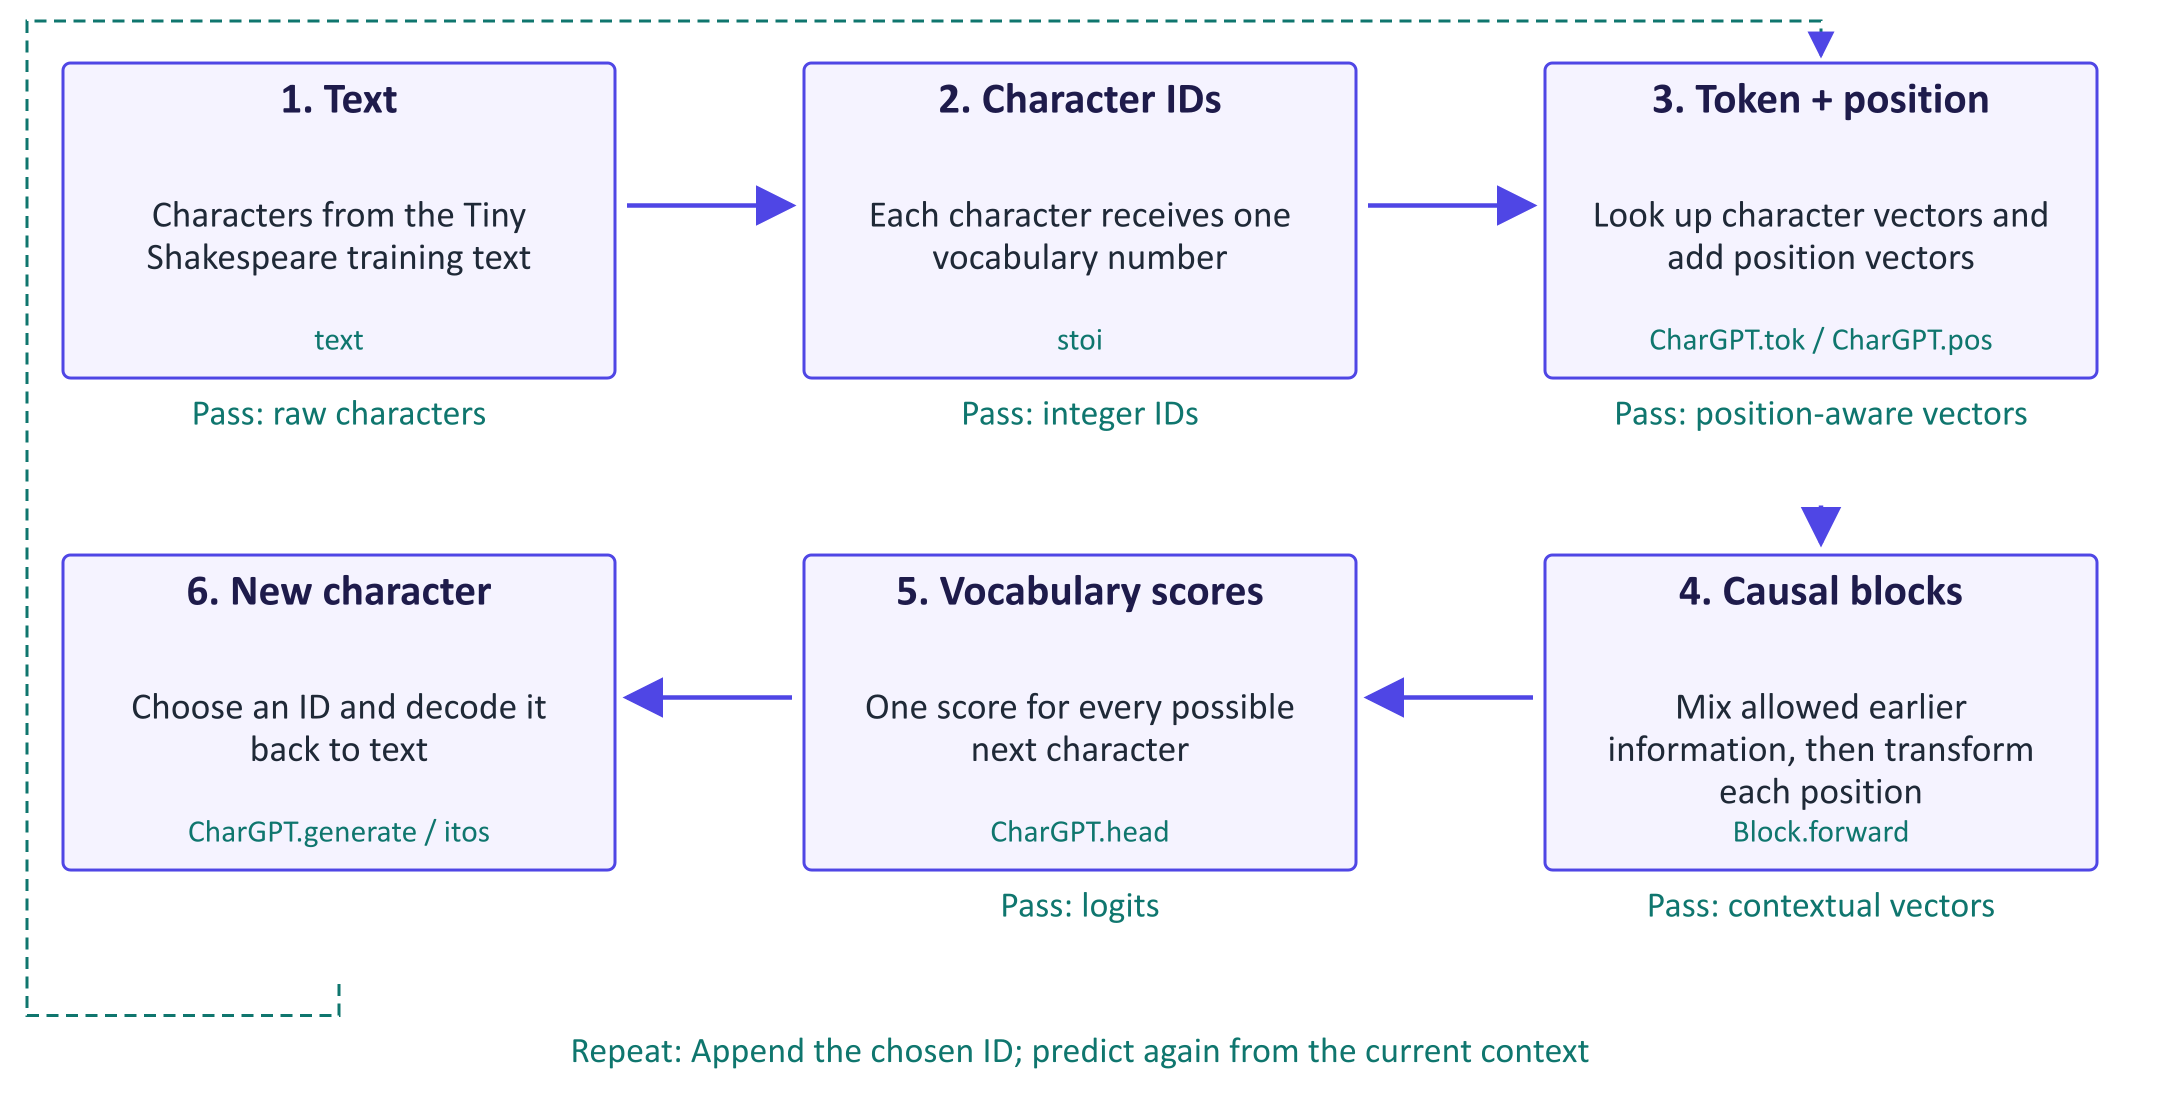

## Your map from blocks to code

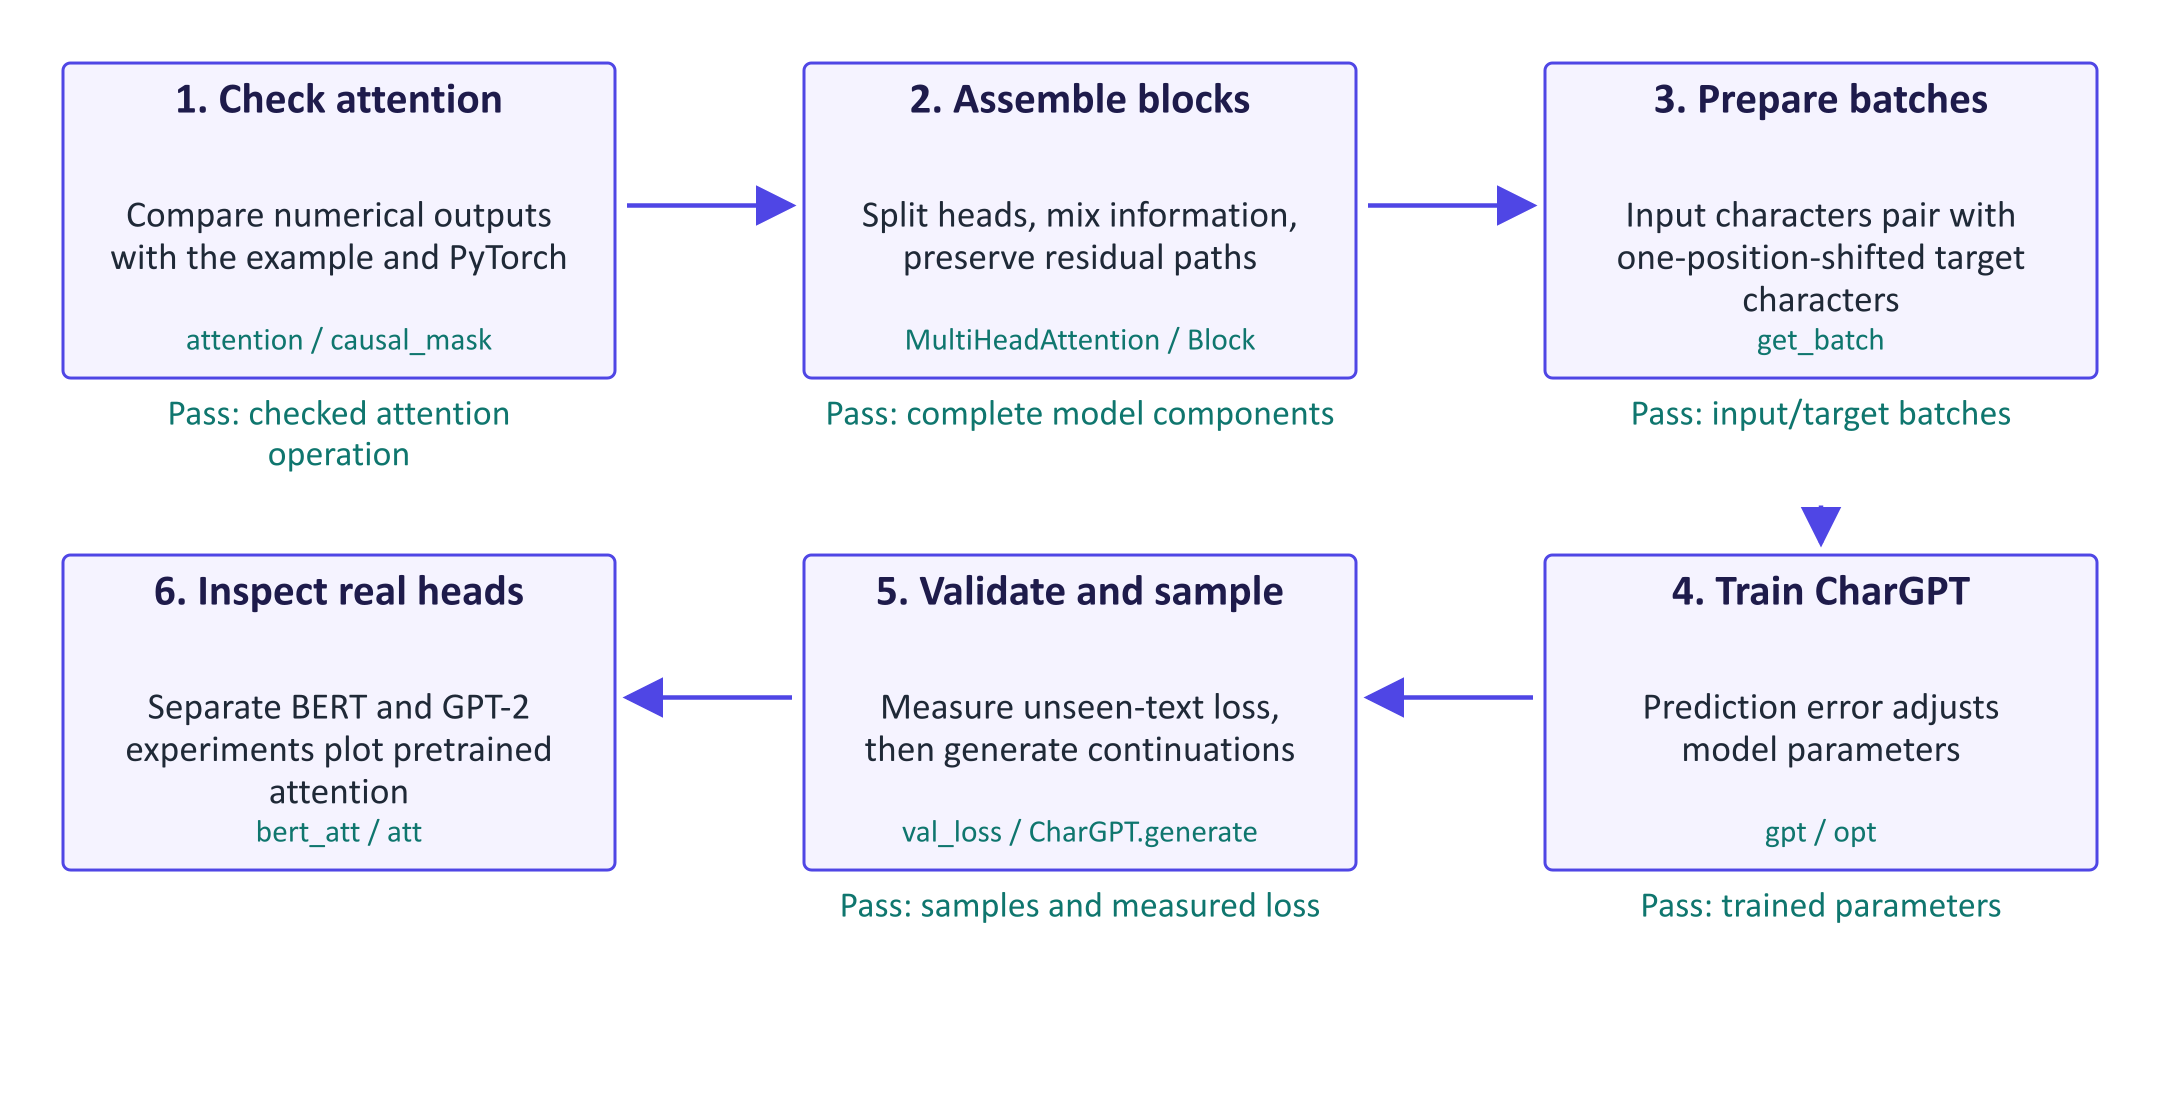

| Block in the map | Find this code | Observe this |
|---|---|---|
| Check attention | `attention`, `causal_mask` | Token-by-token weights and allowed positions |
| Assemble blocks | `MultiHeadAttention`, `Block` | The batch, token, head and feature dimensions |
| Prepare batches | `get_batch` | Input and target characters offset by one position |
| Train | `gpt`, `opt` | Prediction error and the parameters being adjusted |
| Validate and sample | `val_loss`, `CharGPT.generate` | Separate-text error and generated continuations |
| Inspect real heads | `bert_att`, `att` | Separate pretrained models' routing patterns |

Before running a long training cell, explain aloud what goes in, what comes
out, and which check would reveal a mistake. A vector is a list of numbers;
a matrix is a table; a tensor can have several named axes. Print shapes when
the axes become difficult to follow. The code exercises still need your own
implementations in the student notebook.

In [ ]:
%pip install -q torch transformers matplotlib

In [ ]:
import math
import os
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

## Part 1 · Scaled dot-product attention

$$\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

**TODO 1:** implement `attention(q, k, v, mask=None)`. Inputs have shape `[..., n, d_k]`. If `mask` is given (boolean, `True` = **not allowed**), set those scores to `-inf` before the softmax. Return the output **and** the weights.

**Read the shapes first.** `n` counts token positions; `d_k` counts numbers
per query/key vector. A query-by-key score table has two position axes.
Each output row belongs to one query. Values supply the information mixed
into that row; keys supply the matching features. The optional leading axes
can represent batches and heads, and the operation runs independently there.

In [ ]:
def attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = q @ k.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = scores.softmax(dim=-1)
    return weights @ v, weights


# the worked example from the lecture
Q = torch.tensor([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
V = torch.tensor([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]])
out, w = attention(Q, Q, V)
print("weights:\n", w.numpy().round(3))
print("outputs:\n", out.numpy().round(3))
assert torch.allclose(w[2], torch.tensor([0.248, 0.248, 0.503]), atol=2e-3), "row 'mat' should be [0.25, 0.25, 0.50]"

x = torch.randn(2, 4, 7, 16)
ref = F.scaled_dot_product_attention(x, x, x)
assert torch.allclose(attention(x, x, x)[0], ref, atol=1e-5)
print("✅ attention matches the lecture example and torch.nn.functional.scaled_dot_product_attention")

### 1.1 Why divide by √d_k?
Measure the spread of raw dot products for random vectors as the dimension grows, and what it does to the softmax.

In [ ]:
for d in (4, 64, 512):
    a, b = torch.randn(10000, d), torch.randn(10000, d)
    dots = (a * b).sum(-1)
    row = torch.randn(8, d) @ torch.randn(d)
    print(f"d_k={d:4d}: std of q·k = {dots.std():6.2f} | max softmax weight unscaled = {row.softmax(0).max():.3f}, "
          f"scaled = {(row / math.sqrt(d)).softmax(0).max():.3f}")

## Part 2 · Causal masking and the role of position

**TODO 2:** complete `causal_mask(n)`: a boolean `[n, n]` tensor that is `True` **above** the diagonal (future positions).

In [ ]:
def causal_mask(n, device="cpu"):
    return torch.triu(torch.ones(n, n, dtype=torch.bool, device=device), diagonal=1)


m = causal_mask(5)
_, w = attention(torch.randn(5, 8), torch.randn(5, 8), torch.randn(5, 8), mask=m)
print(w.numpy().round(2))
assert torch.all(w[m] == 0), "future positions must get exactly zero weight"
ref = F.scaled_dot_product_attention(x, x, x, is_causal=True)
assert torch.allclose(attention(x, x, x, mask=causal_mask(7))[0], ref, atol=1e-5)
print("✅ causal mask correct")

**Attention ignores order.** Shuffle the tokens of a sequence (without positional information) and compare the outputs.

In [ ]:
tokens = torch.randn(6, 16)
perm = torch.randperm(6)
out1, _ = attention(tokens, tokens, tokens)
out2, _ = attention(tokens[perm], tokens[perm], tokens[perm])
print("outputs of shuffled input == shuffled outputs:", torch.allclose(out1[perm], out2, atol=1e-6))

✍️ **Question 1.** What does this experiment show, and how do transformers fix it? Name two positional-encoding methods.

**✅ Model answer:**
Self-attention is permutation-equivariant: shuffling the input tokens simply shuffles the outputs in the same way, so without extra information the model cannot distinguish "dog bites man" from "man bites dog". Transformers therefore add positional information to the token embeddings: fixed sinusoidal encodings (original transformer), learned absolute position embeddings (BERT, GPT-2), or rotary position embeddings (RoPE), which rotate queries and keys so that attention scores depend on relative distance (used by LLaMA-family and most current open LLMs). A causal mask also breaks the symmetry for decoders, but it only tells a token which tokens came before it, not their exact positions.

## Part 3 · Multi-head attention and a transformer block

**TODO 3:** complete `MultiHeadAttention.forward`: project to Q, K, V, **split into heads** (shape `[batch, heads, n, d_head]`), apply your `attention`, **merge heads** back to `[batch, n, d_model]`, apply the output projection.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.h, self.dh = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        # x uses [batch, token positions, model features]; keep these axes distinct.
        b, n, d = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = (t.view(b, n, self.h, self.dh).transpose(1, 2) for t in (q, k, v))
        out, _ = attention(q, k, v, mask)
        out = out.transpose(1, 2).reshape(b, n, d)
        return self.proj(out)


class Block(nn.Module):
    """Pre-norm transformer block: x + MHA(LN(x)), then x + MLP(LN(x))."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.mlp = nn.Sequential(nn.Linear(d_model, 4 * d_model), nn.GELU(), nn.Linear(4 * d_model, d_model), nn.Dropout(dropout))

    def forward(self, x, mask):
        # Attention exchanges information across positions; the MLP acts per position.
        x = x + self.attn(self.ln1(x), mask)
        return x + self.mlp(self.ln2(x))


mha = MultiHeadAttention(32, 4)
y = mha(torch.randn(2, 10, 32), causal_mask(10))
assert y.shape == (2, 10, 32)
# causality check: changing a future token must not change earlier outputs
xa = torch.randn(1, 10, 32)
xb = xa.clone(); xb[0, 7:] = torch.randn(3, 32)
ya, yb = mha(xa, causal_mask(10)), mha(xb, causal_mask(10))
assert torch.allclose(ya[0, :7], yb[0, :7], atol=1e-5), "outputs before position 7 must not depend on later tokens"
print("✅ multi-head attention: shapes and causality correct")

## Part 4 · Train a character-level GPT on Tiny Shakespeare

In [ ]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
try:
    text = urllib.request.urlopen(URL, timeout=20).read().decode("utf-8")
except Exception as e:  # offline fallback
    print("download failed, using a short built-in text:", e)
    text = ("ROMEO:\nBut soft, what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\n" * 300)
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
VOCAB, CTX = len(chars), 128
print(f"{len(text):,} characters, vocabulary of {VOCAB}")


def get_batch(which, bs=64):
    # The same text chunk provides inputs and known next-character targets.
    d = train_data if which == "train" else val_data
    ix = torch.randint(len(d) - CTX - 1, (bs,))
    xb = torch.stack([d[i:i + CTX] for i in ix])
    yb = torch.stack([d[i + 1:i + CTX + 1] for i in ix])
    return xb.to(DEVICE), yb.to(DEVICE)


class CharGPT(nn.Module):
    def __init__(self, d_model=192, n_heads=6, n_layers=4):
        super().__init__()
        self.tok = nn.Embedding(VOCAB, d_model)
        self.pos = nn.Embedding(CTX, d_model)  # learned absolute positions
        self.blocks = nn.ModuleList([Block(d_model, n_heads) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, VOCAB)

    def forward(self, idx):
        n = idx.size(1)
        # The model receives IDs; token and position tables turn them into vectors.
        x = self.tok(idx) + self.pos(torch.arange(n, device=idx.device))
        mask = causal_mask(n, idx.device)
        for blk in self.blocks:
            x = blk(x, mask)
        return self.head(self.ln(x))

    @torch.no_grad()
    def generate(self, idx, n_new, temperature=1.0):
        for _ in range(n_new):
            # Only the last position predicts the next appended character.
            logits = self(idx[:, -CTX:])[:, -1] / temperature
            idx = torch.cat([idx, torch.multinomial(logits.softmax(-1), 1)], dim=1)
        return idx


@torch.no_grad()
def val_loss(model, batches=10):
    model.eval()
    losses = [F.cross_entropy(model(xb).view(-1, VOCAB), yb.view(-1)).item() for xb, yb in (get_batch("val") for _ in range(batches))]
    model.train()
    return float(np.mean(losses))


gpt = CharGPT().to(DEVICE)
print(f"CharGPT: {sum(p.numel() for p in gpt.parameters()) / 1e6:.2f} M parameters")
opt = torch.optim.AdamW(gpt.parameters(), lr=1e-3)
STEPS = 30 if SMOKE else (3000 if DEVICE == "cuda" else 800)
curve = []
t0 = time.time()
for step in range(STEPS + 1):
    if step % max(1, STEPS // 10) == 0:
        curve.append((step, val_loss(gpt)))
        print(f"step {step:5d}: val loss {curve[-1][1]:.3f}  ({time.time() - t0:.0f} s)")
    if step == STEPS:
        break
    xb, yb = get_batch("train")
    loss = F.cross_entropy(gpt(xb).view(-1, VOCAB), yb.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

c = np.array(curve)
plt.plot(c[:, 0], c[:, 1], marker="o"); plt.axhline(math.log(VOCAB), ls="--", color="gray")
plt.xlabel("step"); plt.ylabel("validation loss (nats/char)"); plt.title("Training a character-level GPT"); plt.show()

**TODO 4:** compute the validation **perplexity** from the final validation loss.

In [ ]:
final_loss = curve[-1][1]
perplexity = math.exp(final_loss)
print(f"validation perplexity = {perplexity:.2f} (uniform guessing would be {VOCAB})")

prompt = torch.tensor([[stoi[ch] for ch in "ROMEO:\n" if ch in stoi]], device=DEVICE)
for T in (0.5, 1.0, 1.5):
    torch.manual_seed(0)
    print(f"\n--- temperature {T} ---")
    print("".join(itos[i] for i in gpt.generate(prompt, 60 if SMOKE else 250, temperature=T)[0].tolist()))

✍️ **Question 2.** Interpret the perplexity. What has the model learned, and what has it clearly not learned? Why is its perplexity not comparable with a sub-word LLM's perplexity?

**✅ Model answer:**
A character perplexity around 4–6 means that, on average, the model is as uncertain as choosing among 4–6 characters, far better than the ~65-way uniform guess. It has learned spelling, common words, punctuation, line breaks, speaker names in capitals and the rhythm of dialogue; at low temperature it repeats common words, at high temperature it invents words. It has not learned meaning, plot or long-range coherence: sentences are grammatical-looking nonsense because it is tiny, trained briefly and sees only 128 characters of context. Perplexity depends on the unit being predicted: predicting one character among ~65 is a different task from predicting one sub-word among ~50,000, so perplexities are only comparable with the same tokeniser and test text (one could compare bits per character instead).

## Part 5 · Interrogating real transformers

We load pretrained **BERT** (encoder) and **GPT-2** (decoder) and ask them to return their attention weights.

In [ ]:
from transformers import AutoModel, AutoTokenizer

sentence = "The animal didn't cross the street because it was too tired."
bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", attn_implementation="eager").eval()
enc = bert_tok(sentence, return_tensors="pt")
with torch.no_grad():
    bert_att = torch.stack(bert(**enc, output_attentions=True).attentions)[:, 0]  # [layers, heads, n, n]
toks = bert_tok.convert_ids_to_tokens(enc["input_ids"][0])
i_it, i_animal, i_street = toks.index("it"), toks.index("animal"), toks.index("street")
print(f"BERT: {bert_att.shape[0]} layers × {bert_att.shape[1]} heads")

**TODO 5:** find the (layer, head) where the token `it` gives the **highest** attention weight to `animal`, and plot that head's full attention matrix.

In [ ]:
scores = bert_att[:, :, i_it, i_animal]
layer, head = divmod(int(scores.argmax()), scores.shape[1])
print(f"layer {layer + 1}, head {head + 1}: weight it→animal = {bert_att[layer, head, i_it, i_animal]:.2f}, it→street = {bert_att[layer, head, i_it, i_street]:.2f}")
plt.figure(figsize=(7, 6))
plt.imshow(bert_att[layer, head].numpy(), cmap="Purples")
plt.xticks(range(len(toks)), toks, rotation=70); plt.yticks(range(len(toks)), toks)
plt.title(f"BERT layer {layer + 1}, head {head + 1}"); plt.colorbar(); plt.show()

# how typical is this? distribution of it→animal weight across all heads
plt.hist(bert_att[:, :, i_it, i_animal].flatten().numpy(), bins=30)
plt.xlabel("attention weight it→animal"); plt.ylabel("number of heads"); plt.title("Across all 144 heads"); plt.show()

Now the same sentence in GPT-2 (causal). Change the sentence to "...because
it was too **wide**." and compare where `it` attends. Both adjectives occur
**after** `it`: its representation and attention row cannot use either one.
With the same prefix through `it`, that row should therefore be unchanged.
This checks the causal mask; it does not test whether GPT-2 can use the full
sentence to resolve the referent. A later position can use the adjective.

In [ ]:
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", attn_implementation="eager").eval()
for s in (sentence, sentence.replace("tired", "wide")):
    ids = gpt2_tok(s, return_tensors="pt")
    with torch.no_grad():
        att = torch.stack(gpt2(**ids, output_attentions=True).attentions)[:, 0]
    gt = gpt2_tok.convert_ids_to_tokens(ids["input_ids"][0])
    j_it = [k for k, t in enumerate(gt) if t.strip("Ġ") == "it"][0]
    j_an = [k for k, t in enumerate(gt) if t.strip("Ġ") == "animal"][0]
    j_st = [k for k, t in enumerate(gt) if t.strip("Ġ") == "street"][0]
    avg = att[:, :, j_it].mean(dim=(0, 1))  # average over all layers and heads
    print(f"{s[-12:]!r}: mean attention it→animal {avg[j_an]:.3f}, it→street {avg[j_st]:.3f}")

✍️ **Question 3.** Does the attention plot *explain* why BERT links "it" to "animal"? Give two reasons to be cautious, using what you saw (e.g. the histogram across heads and the "tired" vs "wide" comparison).

**✅ Model answer:**
It shows that at least one head routes information from "animal" into the representation of "it", which is consistent with coreference, but it does not explain the model's decision. Cautions: (1) we selected the single head that shows the pattern out of 144; the histogram shows most heads give "animal" little weight, so this is selected rather than representative evidence. (2) Attention weights alone are not a faithful explanation: information is also mixed by the MLPs, residual stream and value vectors, and research (e.g. Jain & Wallace, 2019) has shown attention can be altered without changing predictions. (3) GPT-2's attention at "it" is unchanged when the later adjective changes because the causal mask blocks both "tired" and "wide" from that earlier position. This is expected causality, not evidence that GPT-2 failed to reason about the complete sentence. To test its use of the adjective, examine a later position or a prediction made after the full sentence. Faithful explanation needs controlled interventions (ablation, probing, causal tracing), not plots alone.

## Part 6 · Optional: the KV cache
Time GPT-2 generation with the cache on (default) and off.

In [ ]:
from transformers import AutoModelForCausalLM

lm = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()
ids = gpt2_tok("Once upon a time", return_tensors="pt").to(DEVICE)
n_new = 10 if SMOKE else 200
for use_cache in (True, False):
    t0 = time.time()
    with torch.no_grad():
        lm.generate(**ids, max_new_tokens=n_new, min_new_tokens=n_new, do_sample=False, use_cache=use_cache, pad_token_id=gpt2_tok.eos_token_id)
    print(f"use_cache={use_cache}: {time.time() - t0:.2f} s for {n_new} tokens")

| Check | Result |
|---|---|
| attention matches PyTorch | ✅ / ❌ |
| multi-head causal check | ✅ / ❌ |
| final validation loss / perplexity | |
| best BERT head for it→animal | |
| KV-cache speed-up | |

**Before next week:** watch Karpathy's *Intro to Large Language Models* (1 h) and skim Tunstall et al. ch. 1.